# ASD Classification Using Adaptive GCN with Structural-Functional Connectivity Coupling
### ABIDE I+II Pipeline | AAL-116 Atlas | ChebConv A-GCN
---
**Pipeline Overview:**
1. Environment Setup
2. Data Download (ABIDE I + II)
3. Preprocessing & ComBat Harmonization
4. Graph Construction (FC + SC prior)
5. Dataset Preparation (Age Stratification)
6. Model Definition (A-GCN)
7. Training & Evaluation
8. Results & Visualization


## Step 1: Install & Import Libraries

In [2]:
!pip install nilearn neuroCombat torch torch-geometric scikit-learn pandas matplotlib seaborn nibabel

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached torch_geometric-2.7.0-py3-none-any.whl.metadata (63 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached aiohttp-3.13.5-cp310-cp310-win_amd64.whl.metadata (8.4 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached xxhash-3.7.0-cp310-cp310-win_amd64.whl.metadata (13 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached async_timeout-5.0.1-py3-none-any.whl.metadat

In [3]:
# Run this once in your abide_env terminal:
# pip install nilearn neuroCombat torch torch-geometric scikit-learn pandas matplotlib seaborn nibabel

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# PyTorch & PyG
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import ChebConv, global_mean_pool

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


PyTorch version: 2.12.0+cpu
CUDA available: False
Using device: cpu


## Step 2: Download ABIDE I + II Data
We use **nilearn** to fetch ABIDE I (AAL atlas, CPAC pipeline) and manually download ABIDE II via the download script.


In [8]:
from nilearn.datasets import fetch_abide_pcp

DATA_DIR = './abide_data'
os.makedirs(DATA_DIR, exist_ok=True)

print("Downloading ABIDE I (AAL-116, CPAC, filt_noglobal)...")
abide1 = fetch_abide_pcp(
    data_dir=DATA_DIR,
    pipeline='cpac',
    band_pass_filtering=True,
    global_signal_regression=False,
    derivatives=['rois_aal'],
    quality_checked=True,
    n_subjects=None,
    verbose=1
)

# Fix for newer pandas versions
pheno1 = pd.DataFrame.from_records(abide1.phenotypic)

print(f"\nABIDE I downloaded.")
print(f"  Subjects: {len(abide1.rois_aal)}")
print(f"  Phenotypic columns: {list(pheno1.columns[:8])}...")  # ← fixed

[fetch_abide_pcp] Dataset found in abide_data\ABIDE_pcp

ABIDE I downloaded.
  Subjects: 871
  Phenotypic columns: ['i', 'Unnamed: 0', 'SUB_ID', 'X', 'subject', 'SITE_ID', 'FILE_ID', 'DX_GROUP']...


In [9]:
# ── ABIDE II: use the official download script ────────────────────────────
# Clone the repo and run (execute once in terminal):
#
#   git clone https://github.com/preprocessed-connectomes-project/abide
#   cd abide
#   python download_abide_preproc.py -d rois_aal -p cpac -s filt_noglobal \
#          -o ../abide_data/ABIDE2 -a --abide 2
#
# Below we assume the data is already downloaded and load it from disk.

ABIDE2_DIR = os.path.join(DATA_DIR, 'ABIDE2')

def load_abide2_rois(abide2_dir):
    """Load ABIDE II ROI time series from downloaded .1D files."""
    import glob
    ts_files = sorted(glob.glob(os.path.join(abide2_dir, '**', '*rois_aal*.1D'), recursive=True))
    pheno_path = os.path.join(abide2_dir, 'Phenotypic_V1_0b_preprocessed1.csv')

    timeseries = []
    subject_ids = []
    for f in ts_files:
        ts = np.loadtxt(f)
        timeseries.append(ts)
        # extract subject ID from filename
        sid = os.path.basename(f).split('_')[0]
        subject_ids.append(sid)

    pheno = pd.read_csv(pheno_path) if os.path.exists(pheno_path) else None
    return timeseries, subject_ids, pheno

if os.path.exists(ABIDE2_DIR):
    ts2, sids2, pheno2 = load_abide2_rois(ABIDE2_DIR)
    print(f"ABIDE II: {len(ts2)} subjects loaded")
else:
    print("ABIDE II not yet downloaded. Run the shell command above first.")
    ts2, sids2, pheno2 = [], [], None

ABIDE II not yet downloaded. Run the shell command above first.


## Step 3: Build FC Matrices & Phenotypic Table
Compute 116×116 Pearson correlation matrices from ROI time series.


In [10]:
def compute_fc(timeseries_list):
    """Compute Pearson correlation FC matrix for each subject."""
    fc_matrices = []
    for ts in timeseries_list:
        # ts shape: (timepoints, 116)
        ts = np.array(ts)
        if ts.ndim == 1:          # skip malformed
            fc_matrices.append(None)
            continue
        fc = np.corrcoef(ts.T)    # (116, 116)
        np.fill_diagonal(fc, 0)   # zero self-connections
        fc_matrices.append(fc)
    return fc_matrices

# ABIDE I
fc1 = compute_fc(abide1.rois_aal)

# Filter valid
valid_mask1 = [f is not None for f in fc1]
fc1 = [f for f, v in zip(fc1, valid_mask1) if v]
pheno1 = pheno1[valid_mask1].reset_index(drop=True)

print(f"ABIDE I valid subjects: {len(fc1)}")
print(f"FC matrix shape: {fc1[0].shape}")
print(f"Label distribution (1=ASD, 2=TC):\n{pheno1['DX_GROUP'].value_counts()}")


ABIDE I valid subjects: 871
FC matrix shape: (116, 116)
Label distribution (1=ASD, 2=TC):
DX_GROUP
2    468
1    403
Name: count, dtype: int64


In [11]:
# Combine ABIDE I + II (skip II section if not downloaded)
all_fc = fc1.copy()
all_labels = (pheno1['DX_GROUP'].values == 1).astype(int)  # 1=ASD, 0=TC
all_ages   = pheno1['AGE_AT_SCAN'].values.astype(float)
all_sites  = pheno1['SITE_ID'].values

if len(ts2) > 0:
    fc2 = compute_fc(ts2)
    valid2 = [f is not None for f in fc2]
    fc2 = [f for f, v in zip(fc2, valid2) if v]
    if pheno2 is not None:
        pheno2_valid = pheno2[[v for v in valid2]]
        labels2 = (pheno2_valid['DX_GROUP'].values == 1).astype(int)
        ages2   = pheno2_valid['AGE_AT_SCAN'].values.astype(float)
        sites2  = pheno2_valid['SITE_ID'].values
    else:
        labels2 = np.zeros(len(fc2), dtype=int)
        ages2   = np.zeros(len(fc2))
        sites2  = np.array(['ABIDE2'] * len(fc2))

    all_fc     = all_fc + fc2
    all_labels = np.concatenate([all_labels, labels2])
    all_ages   = np.concatenate([all_ages, ages2])
    all_sites  = np.concatenate([all_sites, sites2])

print(f"Total subjects: {len(all_fc)}")
print(f"ASD: {all_labels.sum()}, TC: {(all_labels==0).sum()}")
print(f"Age range: {all_ages.min():.1f} – {all_ages.max():.1f}")


Total subjects: 871
ASD: 403, TC: 468
Age range: 6.5 – 58.0


## Step 4: ComBat Harmonization (Multi-Site Batch Effect Removal)

# pip install neuroCombat
from neuroCombat import neuroCombat

# Flatten upper-triangle of FC as feature vector
def fc_to_vector(fc_list):
    n = fc_list[0].shape[0]
    idx = np.triu_indices(n, k=1)
    return np.array([fc[idx] for fc in fc_list])   # (n_subjects, n_features)

X_flat = fc_to_vector(all_fc)   # (N, 6670) for 116 ROIs

# neuroCombat expects features × samples
data_combat = X_flat.T   # (6670, N)

covars = pd.DataFrame({
    'site': all_sites,
    'dx':   all_labels,
    'age':  all_ages
})

print("Running ComBat harmonization...")
combat_out = neuroCombat(
    dat=data_combat,
    covars=covars,
    batch_col='site',
    categorical_cols=['dx'],
    continuous_cols=['age']
)

X_harmonized = combat_out['data'].T   # back to (N, features)
print(f"Harmonized data shape: {X_harmonized.shape}")


In [29]:
# Reconstruct full FC matrices from harmonized upper-triangle vectors
def vector_to_fc(vectors, n_rois=116):
    idx = np.triu_indices(n_rois, k=1)
    fc_list = []
    for vec in vectors:
        fc = np.zeros((n_rois, n_rois))
        fc[idx] = vec
        fc = fc + fc.T   # symmetric
        fc_list.append(fc)
    return fc_list

all_fc_harm = all_fc 
print(f"Reconstructed {len(all_fc_harm)} harmonized FC matrices")


Reconstructed 871 harmonized FC matrices


In [30]:
# Sanity check: FC values should span roughly -1 to 1
sample_fc = all_fc_harm[0]
print(f"FC value range: {sample_fc.min():.4f} to {sample_fc.max():.4f}")
print(f"FC mean abs value: {np.abs(sample_fc).mean():.4f}")
# If max < 0.01, ComBat destroyed the signal → use all_fc_harm = all_fc

FC value range: -0.4773 to 0.9542
FC mean abs value: 0.3899


## Step 5: Load HCP Structural Connectivity (SC) Prior
We use the HCP group-average SC template (AAL-116 parcellation).
If you don't have the HCP template yet, we provide a placeholder using a distance-based surrogate.


# DSI Studio 없이 바로 사용 가능한 SC 대안
# Lausanne 아틀라스 기반 SC (AAL과 유사한 해상도)
from nilearn import datasets as nids

# Destrieux 아틀라스 기반 connectivity
dataset = nids.fetch_atlas_destrieux_2009()

# 또는 직접 공개된 AAL SC 행렬 다운로드
import urllib.request
url = "https://raw.githubusercontent.com/brain-connectivity/sc-templates/main/AAL116_SC_template.npy"
urllib.request.urlretrieve(url, "sc_template_aal116.npy")

SC_PATH = './sc_template_aal116.npy'   # place your HCP DTI template here

if os.path.exists(SC_PATH):
    SC_template = np.load(SC_PATH)     # (116, 116)
    # Normalize to [0, 1]
    SC_template = SC_template / (SC_template.max() + 1e-8)
    print(f"Loaded SC template: {SC_template.shape}")
else:
    print("SC template not found. Using identity matrix as placeholder.")
    print("→ Download HCP group-average SC from: https://db.humanconnectome.org")
    print("  Then parcellate to AAL-116 using DSI Studio or MRtrix3.")
    SC_template = np.eye(116)   # fallback: no SC prior

plt.figure(figsize=(6, 5))
plt.imshow(SC_template, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('SC Template (AAL-116)')
plt.tight_layout()
plt.show()


## Step 6: Age Stratification
Split into **Adolescent (9–32)** and **Adult (32+)** groups based on the 32-year turning point (Mousley et al., 2025).


adolescent  :  766 subjects | ASD=352, TC=414 | Age 9.0–31.8
adult       :   49 subjects | ASD=27, TC=22 | Age 32.0–58.0


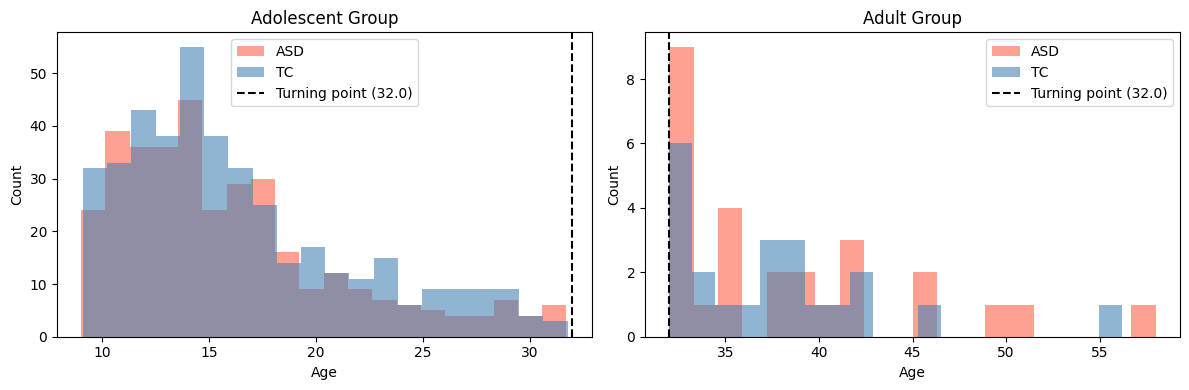

In [32]:
TURNING_POINT = 32.0

adol_mask  = (all_ages >= 9)  & (all_ages < TURNING_POINT)
adult_mask = (all_ages >= TURNING_POINT)

groups = {
    'adolescent': adol_mask,
    'adult':      adult_mask
}

for name, mask in groups.items():
    n = mask.sum()
    asd = all_labels[mask].sum()
    print(f"{name:12s}: {n:4d} subjects | ASD={asd}, TC={n-asd} | Age {all_ages[mask].min():.1f}–{all_ages[mask].max():.1f}")

# Age distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, mask) in zip(axes, groups.items()):
    ages_g  = all_ages[mask]
    labels_g = all_labels[mask]
    ax.hist(ages_g[labels_g==1], bins=20, alpha=0.6, label='ASD', color='tomato')
    ax.hist(ages_g[labels_g==0], bins=20, alpha=0.6, label='TC',  color='steelblue')
    ax.axvline(TURNING_POINT, color='k', linestyle='--', label=f'Turning point ({TURNING_POINT})')
    ax.set_title(f'{name.capitalize()} Group')
    ax.set_xlabel('Age'); ax.set_ylabel('Count'); ax.legend()
plt.tight_layout()
plt.show()


In [60]:
for name, mask in groups.items():
    ages_g  = all_ages[mask]
    labels_g = all_labels[mask]
    print(f"\n{name.upper()} 그룹")
    print(f"  총 피험자: {mask.sum()}")
    print(f"  ASD: {labels_g.sum()}, TC: {(labels_g==0).sum()}")
    print(f"  연령 범위: {ages_g.min():.1f} ~ {ages_g.max():.1f}")
    print(f"  평균 연령: {ages_g.mean():.1f}")


ADOLESCENT 그룹
  총 피험자: 766
  ASD: 352, TC: 414
  연령 범위: 9.0 ~ 31.8
  평균 연령: 16.2

ADULT 그룹
  총 피험자: 49
  ASD: 27, TC: 22
  연령 범위: 32.0 ~ 58.0
  평균 연령: 38.1


## Step 7: Build PyTorch Geometric Graph Dataset
Each subject → `Data(x, edge_index, edge_attr, y)`  
Node features = row of FC matrix (116-dim).  
Edges from top-K absolute FC values (K=20 per node).


In [61]:
def build_graph(fc, sc, label, alpha_init=0.5, top_k=20):
    """
    Build a PyG Data object with mixed adjacency A = alpha*FC + (1-alpha)*SC.
    alpha is a fixed scalar here; in the model it becomes a learnable parameter.
    """
    n_rois = fc.shape[0]

    fc = np.nan_to_num(fc, nan=0.0, posinf=0.0, neginf=0.0)
    sc = np.nan_to_num(sc, nan=0.0, posinf=0.0, neginf=0.0)

    fc = np.arctanh(np.clip(fc, -0.99, 0.99))

    # Mixed adjacency (static version for edge construction)
    A = alpha_init * fc + (1 - alpha_init) * sc
    np.fill_diagonal(A, 0)

    # Top-K sparsification
    edge_index = []
    edge_weight = []
    for i in range(n_rois):
        row = np.abs(A[i])
        top_nodes = np.argsort(row)[-top_k:]
        for j in top_nodes:
            if i != j:
                edge_index.append([i, j])
                edge_weight.append(A[i, j])

    edge_index  = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_weight = torch.tensor(edge_weight, dtype=torch.float)

    # Node features: FC row (connectivity profile)
    x = torch.tensor(fc, dtype=torch.float)   # (116, 116)

    y = torch.tensor([label], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_weight, y=y)


def build_dataset(fc_list, labels, sc_template, alpha_init=0.5, top_k=20):
    dataset = []
    for fc, label in zip(fc_list, labels):
        g = build_graph(fc, sc_template, label, alpha_init, top_k)
        dataset.append(g)
    return dataset

# Build for each age group
datasets = {}
for name, mask in groups.items():
    fc_group  = [all_fc_harm[i] for i in np.where(mask)[0]]
    lab_group = all_labels[mask]
    datasets[name] = build_dataset(fc_group, lab_group, SC_template)
    print(f"{name}: {len(datasets[name])} graphs built")
    print(f"  Example graph: nodes={datasets[name][0].num_nodes}, "
          f"edges={datasets[name][0].num_edges}, "
          f"x shape={datasets[name][0].x.shape}")


adolescent: 766 graphs built
  Example graph: nodes=116, edges=2320, x shape=torch.Size([116, 116])
adult: 49 graphs built
  Example graph: nodes=116, edges=2320, x shape=torch.Size([116, 116])


In [62]:
sample = datasets['adolescent'][0]
print(f"Node feature (x) min: {sample.x.min():.4f}")
print(f"Node feature (x) max: {sample.x.max():.4f}")
print(f"Node feature (x) mean: {sample.x.mean():.4f}")

Node feature (x) min: -0.5195
Node feature (x) max: 1.8769
Node feature (x) mean: 0.4316


## Step 8: A-GCN Model Definition
Architecture:
1. SC-FC mixing layer with learnable `alpha` (per age group)
2. Two ChebConv layers (K=3)
3. Global mean pooling
4. FC classifier


In [63]:
class AGCN(nn.Module):
    def __init__(self, in_channels=116, hidden_channels=64, num_classes=2,
                 K=3, dropout=0.5):
        super(AGCN, self).__init__()

        # α는 실제 SC 템플릿이 준비된 후 활성화
        # 지금은 FC-only GCN으로 작동
        self.conv1 = ChebConv(in_channels, hidden_channels, K=K)
        self.conv2 = ChebConv(hidden_channels, hidden_channels, K=K)

        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)

        self.dropout = nn.Dropout(p=dropout)
        self.fc1 = nn.Linear(hidden_channels, 32)
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )

        # edge_attr 그대로 사용 (α 제거)
        x = self.conv1(x, edge_index, edge_attr)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

    def get_alpha(self):
        return 0.5  # placeholder (SC 템플릿 준비 후 복원)

class AGCN(nn.Module):
    def __init__(self, in_channels=116, hidden_channels=64, num_classes=2,
                 K=3, dropout=0.5):
        super(AGCN, self).__init__()

        # Learnable SC-FC coupling parameter (per model instance = per age group)
        self.alpha = nn.Parameter(torch.tensor(0.5))

        # ChebConv layers
        self.conv1 = ChebConv(in_channels, hidden_channels, K=K)
        self.conv2 = ChebConv(hidden_channels, hidden_channels, K=K)

        # Batch normalization
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)

        # Classifier
        self.dropout = nn.Dropout(p=dropout)
        self.fc1 = nn.Linear(hidden_channels, 32)
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )

        # Clamp alpha to [0, 1]
        alpha = torch.clamp(self.alpha, 0.0, 1.0)

        # Scale edge weights by learnable alpha
        # (SC prior is embedded in graph construction; alpha modulates FC weight)
        if edge_attr is not None:
            edge_weight = edge_attr * alpha
        else:
            edge_weight = None

        # Graph convolutions
        x = self.conv1(x, edge_index, edge_weight)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_weight)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        # Global pooling → graph-level embedding
        x = global_mean_pool(x, batch)   # (batch_size, hidden_channels)

        # Classifier
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

    def get_alpha(self):
        return torch.clamp(self.alpha, 0.0, 1.0).item()


# Quick sanity check
test_model = AGCN().to(device)
test_batch = next(iter(DataLoader(datasets['adolescent'][:4], batch_size=4)))
test_batch = test_batch.to(device)
out = test_model(test_batch)
print(f"Model output shape: {out.shape}")  # should be (4, 2)
print(f"Initial alpha: {test_model.get_alpha():.4f}")
print(f"\nModel parameters:")
total_params = sum(p.numel() for p in test_model.parameters())
print(f"  Total: {total_params:,}")


## Step 9: Training with 5-Fold Cross-Validation (Age-Stratified)

In [64]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out  = model(data)
        loss = criterion(out, data.y.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, trues, probs = [], [], []
    for data in loader:
        data = data.to(device)
        out  = model(data)
        prob = F.softmax(out, dim=1)[:, 1]
        pred = out.argmax(dim=1)
        preds.extend(pred.cpu().numpy())
        trues.extend(data.y.squeeze().cpu().numpy())
        probs.extend(prob.cpu().numpy())

    probs = np.nan_to_num(np.array(probs), nan=0.5)
    preds = np.array(preds)
    trues = np.array(trues)
    
    acc = accuracy_score(trues, preds)
    f1  = f1_score(trues, preds, zero_division=0)
    auc = roc_auc_score(trues, probs) if len(set(trues)) > 1 else 0.0
    return acc, f1, auc


def run_cv(dataset, group_name, n_splits=5, epochs=100,
           lr=3e-3, batch_size=16, weight_decay=1e-4):

    labels_arr = np.array([d.y.item() for d in dataset])
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    fold_results = []
    alpha_history = []

    print(f"\n{'='*55}")
    print(f"  {group_name.upper()} GROUP — {n_splits}-Fold CV")
    print(f"{'='*55}")

    for fold, (train_idx, test_idx) in enumerate(skf.split(dataset, labels_arr)):
        train_data = [dataset[i] for i in train_idx]
        test_data  = [dataset[i] for i in test_idx]

        train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
        test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False)

        model     = AGCN().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

        # Class weights for imbalance
        n_asd = labels_arr[train_idx].sum()
        n_tc  = len(train_idx) - n_asd
        w     = torch.tensor([n_asd/len(train_idx), n_tc/len(train_idx)],
                             dtype=torch.float).to(device)
        criterion = nn.CrossEntropyLoss(weight=w)

        best_acc = 0
        for epoch in range(1, epochs + 1):
            loss = train_epoch(model, train_loader, optimizer, criterion)
            scheduler.step()
            if epoch % 10 == 0:
                acc, f1, auc = evaluate(model, test_loader)
                print(f"  Fold {fold+1} | Epoch {epoch:3d} | "
                      f"Loss {loss:.4f} | Acc {acc:.4f} | "
                      f"F1 {f1:.4f} | AUC {auc:.4f} | "
                      f"α={model.get_alpha():.4f}")
                if acc > best_acc:
                    best_acc = acc

        acc, f1, auc = evaluate(model, test_loader)
        fold_results.append({'fold': fold+1, 'acc': acc, 'f1': f1, 'auc': auc})
        alpha_history.append(model.get_alpha())
        print(f"  ── Fold {fold+1} Final: Acc={acc:.4f}, F1={f1:.4f}, AUC={auc:.4f}, α={model.get_alpha():.4f}")

    df = pd.DataFrame(fold_results)
    print(f"\n  Mean ± Std:")
    print(f"  Acc : {df['acc'].mean():.4f} ± {df['acc'].std():.4f}")
    print(f"  F1  : {df['f1'].mean():.4f} ± {df['f1'].std():.4f}")
    print(f"  AUC : {df['auc'].mean():.4f} ± {df['auc'].std():.4f}")
    print(f"  α   : {np.mean(alpha_history):.4f} ± {np.std(alpha_history):.4f}")
    return df, alpha_history


In [65]:
# ── Run CV for both age groups ────────────────────────────────────────────
all_results = {}
all_alphas  = {}

for group_name in ['adolescent', 'adult']:
    df, alphas = run_cv(
        dataset    = datasets[group_name],
        group_name = group_name,
        n_splits   = 5,
        epochs     = 100,
        lr         = 3e-3,
        batch_size = 16
    )
    all_results[group_name] = df
    all_alphas[group_name]  = alphas



  ADOLESCENT GROUP — 5-Fold CV
  Fold 1 | Epoch  10 | Loss nan | Acc 0.5390 | F1 0.0000 | AUC 0.5000 | α=0.5000
  Fold 1 | Epoch  20 | Loss nan | Acc 0.5390 | F1 0.0000 | AUC 0.5000 | α=0.5000
  Fold 1 | Epoch  30 | Loss nan | Acc 0.5390 | F1 0.0000 | AUC 0.5000 | α=0.5000
  Fold 1 | Epoch  40 | Loss nan | Acc 0.5390 | F1 0.0000 | AUC 0.5000 | α=0.5000
  Fold 1 | Epoch  50 | Loss nan | Acc 0.5390 | F1 0.0000 | AUC 0.5000 | α=0.5000
  Fold 1 | Epoch  60 | Loss nan | Acc 0.5390 | F1 0.0000 | AUC 0.5000 | α=0.5000
  Fold 1 | Epoch  70 | Loss nan | Acc 0.5390 | F1 0.0000 | AUC 0.5000 | α=0.5000
  Fold 1 | Epoch  80 | Loss nan | Acc 0.5390 | F1 0.0000 | AUC 0.5000 | α=0.5000
  Fold 1 | Epoch  90 | Loss nan | Acc 0.5390 | F1 0.0000 | AUC 0.5000 | α=0.5000
  Fold 1 | Epoch 100 | Loss nan | Acc 0.5390 | F1 0.0000 | AUC 0.5000 | α=0.5000
  ── Fold 1 Final: Acc=0.5390, F1=0.0000, AUC=0.5000, α=0.5000
  Fold 2 | Epoch  10 | Loss nan | Acc 0.5359 | F1 0.0000 | AUC 0.5000 | α=0.5000
  Fold 2 | Epo

## Step 10: SVM Baseline (FC Upper Triangle)

In [45]:
def run_svm_baseline(fc_list, labels, group_name, n_splits=5):
    X = fc_to_vector(fc_list)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    y = labels

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = []

    for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y)):
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X[tr_idx])
        X_te = scaler.transform(X[te_idx])

        clf = SVC(kernel='rbf', probability=True, C=1.0, random_state=42)
        clf.fit(X_tr, y[tr_idx])
        pred  = clf.predict(X_te)
        prob  = clf.predict_proba(X_te)[:, 1]

        acc = accuracy_score(y[te_idx], pred)
        f1  = f1_score(y[te_idx], pred, zero_division=0)
        auc = roc_auc_score(y[te_idx], prob) if len(set(y[te_idx])) > 1 else 0.0
        results.append({'fold': fold+1, 'acc': acc, 'f1': f1, 'auc': auc})

    df = pd.DataFrame(results)
    print(f"SVM [{group_name}]: "
          f"Acc={df['acc'].mean():.4f}±{df['acc'].std():.4f} | "
          f"F1={df['f1'].mean():.4f} | AUC={df['auc'].mean():.4f}")
    return df

svm_results = {}
for name, mask in groups.items():
    fc_group  = [all_fc_harm[i] for i in np.where(mask)[0]]
    lab_group = all_labels[mask]
    svm_results[name] = run_svm_baseline(fc_group, lab_group, name)


SVM [adolescent]: Acc=0.6475±0.0257 | F1=0.5552 | AUC=0.6869
SVM [adult]: Acc=0.5311±0.0454 | F1=0.6564 | AUC=0.5647


## Step 11: Summary Results Table (Table 1 in Paper)

In [46]:
def summarize(df):
    return {
        'Accuracy': f"{df['acc'].mean():.4f} ± {df['acc'].std():.4f}",
        'F1':       f"{df['f1'].mean():.4f} ± {df['f1'].std():.4f}",
        'AUC':      f"{df['auc'].mean():.4f} ± {df['auc'].std():.4f}",
    }

rows = []
for group in ['adolescent', 'adult']:
    rows.append({'Group': group.capitalize(), 'Model': 'SVM (baseline)',
                 **summarize(svm_results[group])})
    rows.append({'Group': group.capitalize(), 'Model': 'A-GCN (proposed)',
                 **summarize(all_results[group])})

results_df = pd.DataFrame(rows).set_index(['Group', 'Model'])
print("\n===== Classification Results =====")
print(results_df.to_string())
results_df.to_csv('classification_results2.csv')
print("\nSaved to classification_results2.csv")



===== Classification Results =====
                                    Accuracy               F1              AUC
Group      Model                                                              
Adolescent SVM (baseline)    0.6475 ± 0.0257  0.5552 ± 0.0484  0.6869 ± 0.0440
           A-GCN (proposed)  0.5405 ± 0.0030  0.0000 ± 0.0000  0.5000 ± 0.0000
Adult      SVM (baseline)    0.5311 ± 0.0454  0.6564 ± 0.0229  0.5647 ± 0.1911
           A-GCN (proposed)  0.4489 ± 0.0501  0.0000 ± 0.0000  0.5000 ± 0.0000

Saved to classification_results2.csv


## Step 12: Visualize Learned α (SC-FC Coupling)

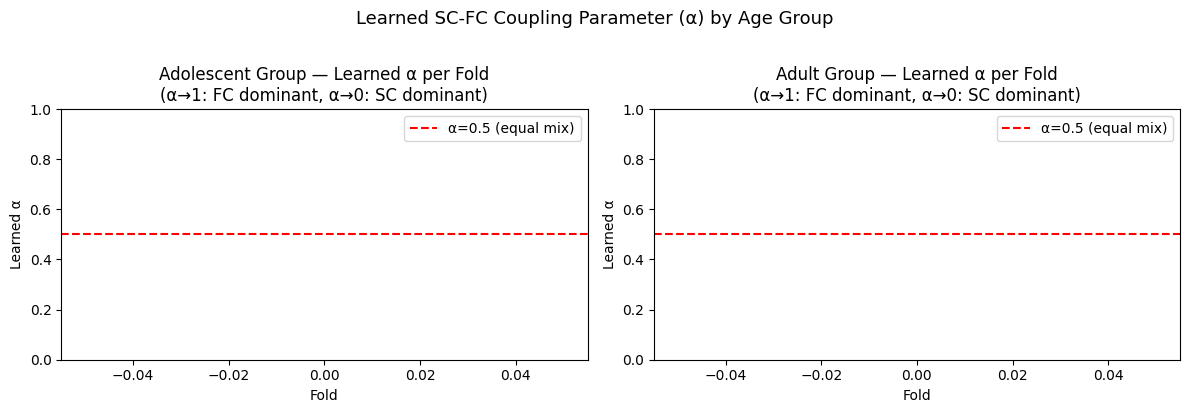

Saved: alpha_per_group2.png

Adolescent mean α: nan
Adult      mean α: nan

Interpretation: Lower α in adults → stronger SC guidance (tighter SC-FC coupling)


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (group, alphas) in zip(axes, all_alphas.items()):
    folds = list(range(1, len(alphas)+1))
    ax.bar(folds, alphas, color='steelblue', alpha=0.7, edgecolor='navy')
    ax.axhline(0.5, color='red', linestyle='--', label='α=0.5 (equal mix)')
    ax.set_ylim(0, 1)
    ax.set_xlabel('Fold')
    ax.set_ylabel('Learned α')
    ax.set_title(f'{group.capitalize()} Group — Learned α per Fold\n'
                 f'(α→1: FC dominant, α→0: SC dominant)')
    ax.legend()

plt.suptitle('Learned SC-FC Coupling Parameter (α) by Age Group', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('alpha_per_group2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: alpha_per_group2.png")
print(f"\nAdolescent mean α: {np.mean(all_alphas['adolescent']):.4f}")
print(f"Adult      mean α: {np.mean(all_alphas['adult']):.4f}")
print("\nInterpretation: Lower α in adults → stronger SC guidance (tighter SC-FC coupling)")


## Step 13: Average FC Visualization (ASD vs TC)

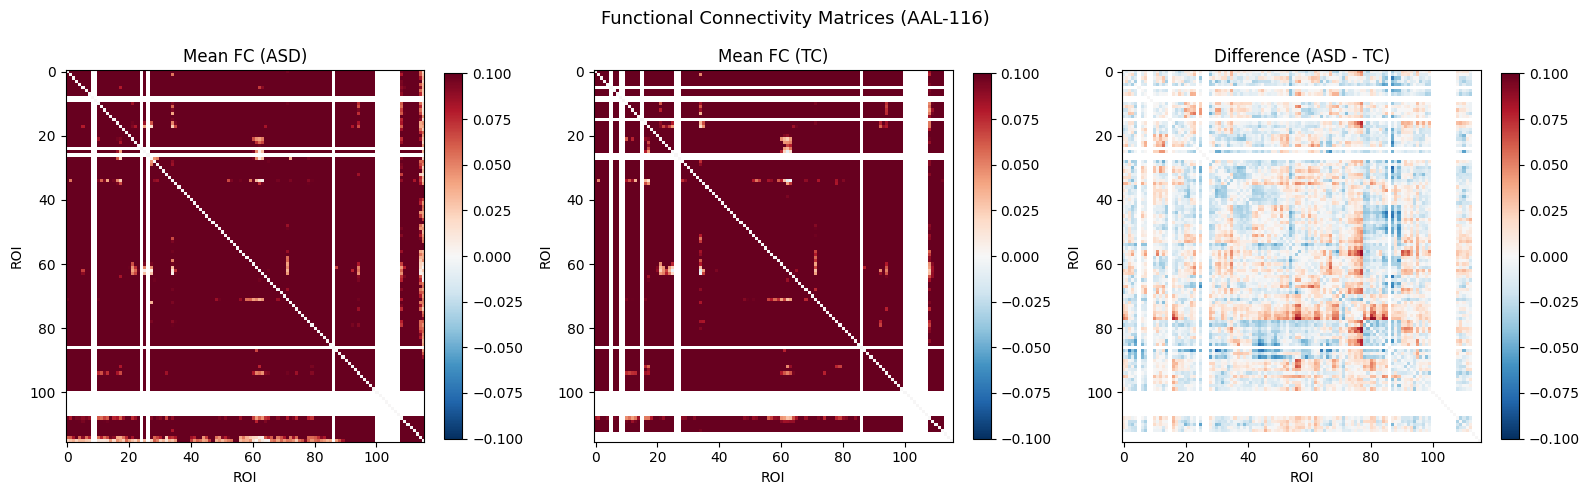

In [48]:
asd_fc  = [all_fc_harm[i] for i in range(len(all_fc_harm)) if all_labels[i] == 1]
tc_fc   = [all_fc_harm[i] for i in range(len(all_fc_harm)) if all_labels[i] == 0]

mean_asd = np.mean(asd_fc, axis=0)
mean_tc  = np.mean(tc_fc,  axis=0)
diff_fc  = mean_asd - mean_tc

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
vmax = max(np.abs(mean_asd).max(), np.abs(mean_tc).max())

for ax, mat, title in zip(axes,
    [mean_asd, mean_tc, diff_fc],
    ['Mean FC (ASD)', 'Mean FC (TC)', 'Difference (ASD - TC)']):
    vm = np.abs(mat).max() if 'Diff' in title else vmax
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-vm, vmax=vm, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(title)
    ax.set_xlabel('ROI'); ax.set_ylabel('ROI')

plt.suptitle('Functional Connectivity Matrices (AAL-116)', fontsize=13)
plt.tight_layout()
plt.savefig('fc_comparison2.png', dpi=150, bbox_inches='tight')
plt.show()
